# JSON形式ファイルから座標を読み取って表示

## JSON形式ファイルを読み込むためのライブラリ

In [6]:
import json

## ファイルの読み込み

In [7]:
json_open = open('COCO_val2014_000000000328_keypoints.json', 'r')
json_load = json.load(json_open)

## peopleの中のpose_keypoints_2dの読み出し

In [8]:
print(json_load['people'][0]['pose_keypoints_2d'])

[329.267, 168.944, 0.818966, 339.49, 169.009, 0.833463, 296.35, 154.679, 0.856826, 269.577, 218.266, 0.684078, 292.241, 234.71, 0.408008, 384.698, 179.241, 0.863105, 394.954, 251.179, 0.837319, 355.931, 255.188, 0.888282, 318.961, 263.486, 0.78128, 288.178, 257.296, 0.763335, 259.383, 275.792, 0.82011, 257.341, 419.606, 0.721428, 347.75, 269.643, 0.762721, 323.092, 298.449, 0.835115, 257.305, 417.546, 0.584621, 320.952, 156.605, 0.927697, 337.553, 156.581, 0.949467, 314.839, 138.108, 0.224352, 355.942, 138.125, 0.824461, 216.204, 450.549, 0.456991, 226.479, 452.492, 0.510273, 269.699, 433.978, 0.348898, 222.341, 452.527, 0.433162, 220.261, 448.369, 0.433577, 271.775, 436.032, 0.509159]


## pose_keypoints_2dの整理

In [9]:
kps = json_load['people'][0]['pose_keypoints_2d']
for i in range(0,3*24+1,3):
    print(i//3, kps[i],kps[i+1],kps[i+2])

0 329.267 168.944 0.818966
1 339.49 169.009 0.833463
2 296.35 154.679 0.856826
3 269.577 218.266 0.684078
4 292.241 234.71 0.408008
5 384.698 179.241 0.863105
6 394.954 251.179 0.837319
7 355.931 255.188 0.888282
8 318.961 263.486 0.78128
9 288.178 257.296 0.763335
10 259.383 275.792 0.82011
11 257.341 419.606 0.721428
12 347.75 269.643 0.762721
13 323.092 298.449 0.835115
14 257.305 417.546 0.584621
15 320.952 156.605 0.927697
16 337.553 156.581 0.949467
17 314.839 138.108 0.224352
18 355.942 138.125 0.824461
19 216.204 450.549 0.456991
20 226.479 452.492 0.510273
21 269.699 433.978 0.348898
22 222.341 452.527 0.433162
23 220.261 448.369 0.433577
24 271.775 436.032 0.509159


## データをグラフで表示

In [10]:
import matplotlib.pyplot as plt

## つながりの定義

In [11]:
cnt = [(0,1),(1,2),(2,3),(3,4),(1,5),(5,6),(6,7),(1,8),
     (8,9),(9,10),(10,11),
     (8,12),(12,13),(13,14),
     (0,15),(0,16),(15,17),(16,18),
     (14,19),(19,20),(14,21),
     (11,22),(22,23),(11,24)]

## 表示

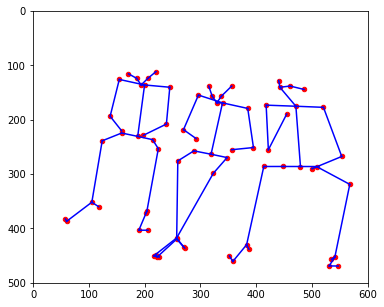

In [12]:
#グラフの設定
fig, ax = plt.subplots(figsize = (6,5))
ax.set_xlim([0,600])
ax.set_ylim([500,0])

#人数分のループ
for k in range(len(json_load['people'])):
    #座標データの読み込み
    kps = json_load['people'][k]['pose_keypoints_2d']
    #点の表示
    for i in range(0,3*24+1,3):
        if kps[i+2]>0:
            ax.scatter(kps[i],kps[i+1],c = 'red', marker='o', s=20)
    #線の表示
    for j in range(len(cnt)):
        i0 = cnt[j][0]*3
        i1 = cnt[j][1]*3
        if kps[i0+2]>0 and kps[i1+2]>0:
            ax.plot((kps[i0],kps[i1]),(kps[i0+1],kps[i1+1]),linestyle='solid',color='blue')
#plt.savefig('pose.pdf')#pdfで保存
#plt.savefig('pose.png')#pngで保存
plt.show()